In [ ]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=46b8ecdd-128e-4596-9c17-98c0930c864c
To: /content/PH2Dataset.rar
100% 162M/162M [00:00<00:00, 196MB/s]


In [ ]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

In [ ]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

In [ ]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [ ]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Посмотрим на датасет

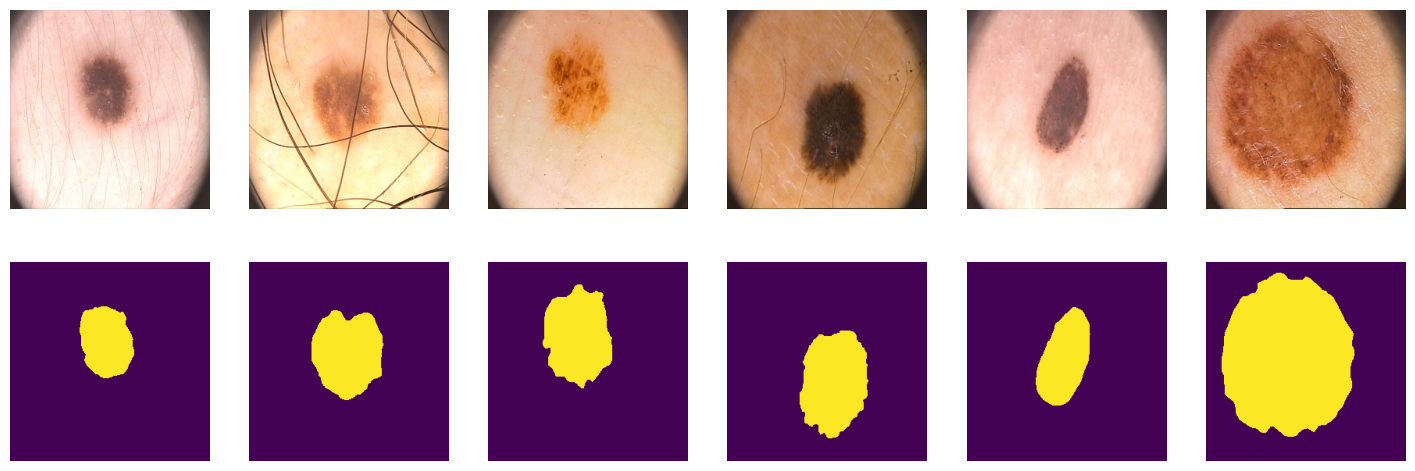

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

In [ ]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [ ]:
print(len(tr), len(val), len(ts))

100 50 50


In [ ]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 61.0 MB/s eta 0:00:00


In [ ]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

In [ ]:
import math

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
bce_torch = nn.BCELoss(reduction='sum')
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

Сделаем BCE Loss

In [ ]:
def bce_loss(y_pred, y_real):
  sum = 0
  siz = len(y_real.size())
  if siz!=4:
    for i in range(len(y_real)):
      for j in range(len(y_real[i])):
        L = y_pred[i][j] - y_real[i][j] * y_pred[i][j] + math.log(1+math.exp(-y_pred[i][j]))
        sum+=L
  if siz==4:
    for i1 in range(y_real.size()[0]):
      for i2 in range(y_real.size()[1]):
        for i3 in range(y_real.size()[2]):
          for i4 in range(y_real.size()[3]):
            L = y_pred[i1][i2][i3][i4] - y_real[i1][i2][i3][i4] * y_pred[i1][i2][i3][i4] + math.log(1+math.exp(-y_pred[i1][i2][i3][i4]))
            sum += L

  return sum

def bce_true(y_pred, y_real):
  sum = 0
  siz = len(y_real.size())
  if siz!=4:
    for i in range(len(y_real)):
      for j in range(len(y_real[i])):
        L = (y_real[i][j] * math.log(torch.sigmoid(y_pred[i][j])) + (1-y_real[i][j]) *  math.log(1 - torch.sigmoid(y_pred[i][j])))
        sum += L
  if siz==4:
    for i1 in range(y_real.size()[0]):
      for i2 in range(y_real.size()[1]):
        for i3 in range(y_real.size()[2]):
          for i4 in range(y_real.size()[3]):
            L = (y_real[i1][i2][i3][i4] * math.log(torch.sigmoid(y_pred[i1][i2][i3][i4])) + (1-y_real[i1][i2][i3][i4]) *  math.log(1 - torch.sigmoid(y_pred[i1][i2][i3][i4])))
            sum += L
  return -sum

Проверим

In [ ]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(y_pred)
print(y_true)
print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


tensor([[-0.1448, -1.2786],
        [ 0.5064, -1.4695],
        [ 1.9166,  0.7719]])
tensor([[0.3245, 0.4861],
        [0.1094, 0.5286],
        [0.9161, 0.7997]])
BCE loss from scratch bce_loss             = 4.276453018188477
BCE loss честно посчитанный                = 4.276453018188477
BCE loss from torch bce_torch              = 4.276452541351318
BCE loss from torch with logits bce_torch  = 4.276453018188477


In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

In [ ]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(y_pred)


print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

tensor([[[[-0.3016, -1.7892,  0.2544],
          [-2.7814,  1.1385,  1.2228],
          [ 0.5031, -0.4775,  0.7323]]],


        [[[-1.4239, -0.0237, -0.8835],
          [ 0.4092, -0.5567,  0.5096],
          [ 0.6140, -0.0582,  0.6504]]]])
BCE loss from scratch bce_loss            = 14.290685653686523
BCE loss честно посчитанный               = 14.290685653686523
BCE loss from torch bce_torch             = 14.29068660736084
BCE loss from torch with logits bce_torch = 14.290685653686523


In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

In [ ]:
Реализуем SegNet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

In [ ]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 169MB/s]


In [ ]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels, indices, out_channels, depth, kernel_size = 3, padding = 1):
        super(DecoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        self.indices = indices
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=False))
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=False))

        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)
  def forward(self, x, indices):
        x = self.unpool(x, indices)
        for layer in self.layers:
            x = layer(x)

        return x


In [ ]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features*2, num_features * 4, depth = 3)
        self.encoder3 = EncoderBlock(num_features*4, num_features * 8, depth = 3)


        self.encoder4 = EncoderBlock(num_features*8, num_features*8, depth = 3)


        self.decoder0 = DecoderBlock(num_features*8, None, num_features*8, depth = 3)

        # Decoder
        self.decoder1 = DecoderBlock(num_features*8, None, num_features*4, depth = 3)
        self.decoder2 = DecoderBlock(num_features*4, None, num_features*2, depth = 3)
        self.decoder3 = DecoderBlock(num_features*2, None, num_features, depth = 2)
        self.decoder4 = DecoderBlock(num_features, None, out_channels, depth = 2)

    def forward(self, x):
        x, indices0 = self.encoder0(x)
        x, indices1 =  self.encoder1(x)
        x, indices2 =  self.encoder2(x)
        x, indices3 =  self.encoder3(x)
        x, indices4 =  self.encoder4(x)
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)
        output = self.decoder4(x, indices0)
        return output

Тренировка модели

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
import torch
from torchmetrics import JaccardIndex

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [ ]:
def train_one_epoch(model, optim, criterion, train_dataloader, device):
  model.train()
  avg_loss = 0
  for X_batch, Y_batch in tqdm(train_dataloader):
    X_batch = X_batch.to(device)
    Y_batch = Y_batch.to(device)

    Y_pred = model(X_batch)
    loss = criterion(Y_pred, Y_batch)
    loss.backward()
    optim.step()
    optim.zero_grad()

    avg_loss += loss

  avg_loss = avg_loss/len(train_dataloader)

  return model, avg_loss

In [ ]:
def train(model, optim, criterion, train_dataloader, device, epochs):
  total_train_loss = []
  for epoch in tqdm(range(epochs)):
    model, train_loss = train_one_epoch(model, optim, criterion, train_dataloader, device)

    total_train_loss.append(train_loss.cpu().detach().numpy())
  return model, total_train_loss

In [ ]:
model = SegNet(out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion =  bce_torch_with_logits
epochs = 21

In [ ]:
model, statistics = train(model, optimizer,criterion, train_dataloader, device, epochs)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
test(model, test_dataloader, device, iou_score)

0.6693957448005676